# Plot all dv/v

This notebook will plot all the dv/v against water level changed published in the literature

In [90]:
!pip install pandas

In [91]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the data from the CSV file
df = pd.read_csv('data/seismic_gwl_data.csv')

# Calculate the medium of the frequency range
df['Seismic frequencies (Hz)'] = df['Seismic frequencies (Hz)'].apply(lambda x: sum(map(float, x.split('-'))) / 2)
df.head()

,Region,Waves used,Single vs array method,Seismic frequencies (Hz),GWL change (m),Pore pressure (Pa),GWL estimate method,dv/v(%),Reference
0,Southern California,coda,array,1.1,16,NaN,Well,0.10,"Mao et al, 2022"
1,California,coda,single,6.0,6,NaN,Rainfall diffusion modeling,1.15,"Clements & Denolle, 2023"
2,Southern California - San Gabriel,coda,array,3.5,25,NaN,GW Well,0.15,"Clements and Denolle, 2018"
3,New Zealand Landslide,coda,Small array,7.0,2,NaN,Piezo @ seismometer borehole @ XM,2.00,"Voisin et al, 2016"
4,"Lyon, France",coda,Small array,3.5,2,NaN,Piezo,2.50,"Gaubert-Bastide et al, 2022"


In [92]:
import numpy as np

# Define constants
rho = 1000  # kg/m^3
g = 9.81  # m/s^2

# Convert Pore Pressure to GWL change where GWL change is NaN
df['GWL change (m)'] = df.apply(
    lambda row: float(row['Pore pressure (Pa)']) / (g * rho) if pd.isna(row['GWL change (m)']) and pd.notna(row['Pore pressure (Pa)']) else row['GWL change (m)'],
    axis=1
)

df.head()

,Region,Waves used,Single vs array method,Seismic frequencies (Hz),GWL change (m),Pore pressure (Pa),GWL estimate method,dv/v(%),Reference
0,Southern California,coda,array,1.1,16,NaN,Well,0.10,"Mao et al, 2022"
1,California,coda,single,6.0,6,NaN,Rainfall diffusion modeling,1.15,"Clements & Denolle, 2023"
2,Southern California - San Gabriel,coda,array,3.5,25,NaN,GW Well,0.15,"Clements and Denolle, 2018"
3,New Zealand Landslide,coda,Small array,7.0,2,NaN,Piezo @ seismometer borehole @ XM,2.00,"Voisin et al, 2016"
4,"Lyon, France",coda,Small array,3.5,2,NaN,Piezo,2.50,"Gaubert-Bastide et al, 2022"


In [93]:
df['GWL change (m)']

0           16
1            6
2           25
3            2
4            2
5            3
6          0.6
7           25
8          0.1
9          0.5
10         1.5
11         0.3
12    0.010194
13        0.15
14         2-5
15         100
16         0.4
17         2.5
18          12
19           7
Name: GWL change (m), dtype: object

In [94]:
# Split the range values and take the mean
df['GWL change (m)'] = df['GWL change (m)'].apply(lambda x: np.mean(list(map(float, x.split('-')))) if '-' in str(x) else float(x))

df.describe()

,Seismic frequencies (Hz),GWL change (m),Pore pressure (Pa),dv/v(%)
count,20.000000,20.000000,3.000000,20.000000
mean,4.625000,10.378010,9233.333333,0.944000
std,5.323385,22.500972,13711.430754,0.976408
min,0.245000,0.010194,100.000000,0.010000
25%,0.625000,0.475000,1350.000000,0.100000
50%,2.875000,2.250000,2600.000000,0.500000
75%,6.625000,8.250000,13800.000000,2.000000
max,21.500000,100.000000,25000.000000,2.500000


In [95]:
df['dv/v(%)']

0     0.10
1     1.15
2     0.15
3     2.00
4     2.50
5     2.50
6     0.60
7     2.00
8     0.01
9     1.00
10    2.50
11    2.00
12    0.02
13    0.02
14    0.03
15    0.10
16    0.20
17    1.50
18    0.10
19    0.40
Name: dv/v(%), dtype: float64

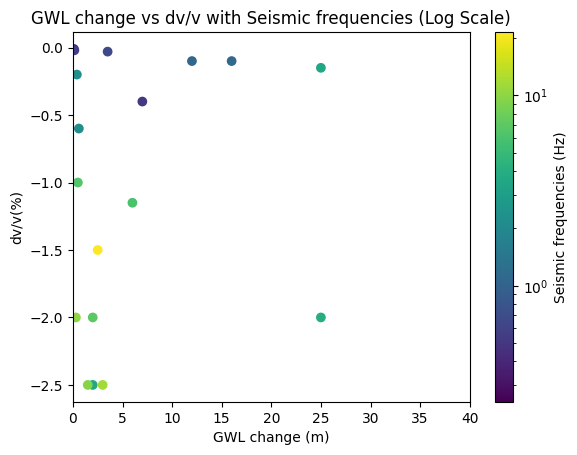

In [96]:
from matplotlib.colors import LogNorm

# Plot the data with a log scale for the color
plt.scatter(df['GWL change (m)'], -df['dv/v(%)'], c=df['Seismic frequencies (Hz)'], cmap='viridis', norm=LogNorm())
plt.colorbar(label='Seismic frequencies (Hz)')
plt.xlabel('GWL change (m)')
plt.ylabel('dv/v(%)')
plt.xlim(0, 40)
plt.title('GWL change vs dv/v with Seismic frequencies (Log Scale)')
plt.show()

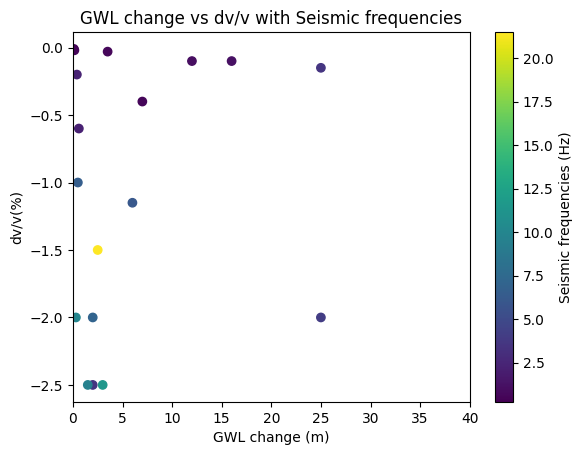

In [97]:

# Plot the data
plt.scatter(df['GWL change (m)'], -df['dv/v(%)'], c=df['Seismic frequencies (Hz)'], cmap='viridis')
plt.colorbar(label='Seismic frequencies (Hz)')
plt.xlabel('GWL change (m)')
plt.ylabel('dv/v(%)')
plt.xlim(0, 40)
plt.title('GWL change vs dv/v with Seismic frequencies')
plt.show()

/var/folders/js/lzmy975n0l5bjbmr9db291m00000gn/T/ipykernel_68363/2945956560.py:50: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 150)


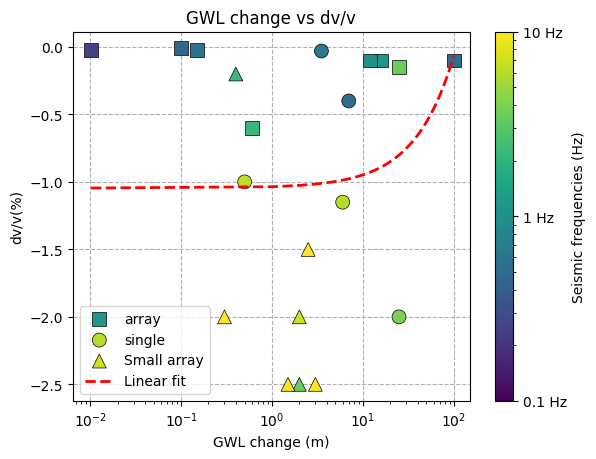

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Define marker styles for each category
marker_styles = {
    'array': 's',  # square
    'single': 'o',  # circle
    'Small array': '^'  # triangle
}


# Set fixed bounds for the colorbar
vmin = 0.1  # Minimum value for the color scale
vmax = 10  # Maximum value for the color scale

# Create a scatter plot with different markers
for category, marker in marker_styles.items():
    subset = df[df['Single vs array method'] == category]
    sc = plt.scatter(subset['GWL change (m)'], -subset['dv/v(%)'], 
                c=subset['Seismic frequencies (Hz)'], cmap='viridis', 
                norm=LogNorm(vmin=vmin, vmax=vmax), marker=marker, label=category,
                edgecolor='k', linewidth=0.5,s=100,zorder=2)

# Add colorbar with custom ticks for octaves
cbar = plt.colorbar(sc)
cbar.set_label('Seismic frequencies (Hz)')

# Define octave frequencies (example values, adjust as needed)
octave_frequencies = [0.1,1,10]
cbar.set_ticks(octave_frequencies)
cbar.set_ticklabels([f'{freq} Hz' for freq in octave_frequencies])


# Fit a linear model to the data
y = -df['dv/v(%)']
x = df['GWL change (m)']
coefficients = np.polyfit(x, y, 1)
linear_fit = np.poly1d(coefficients)

# Plot the linear reference line
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = linear_fit(x_fit)
plt.plot(x_fit, y_fit, color='red', linestyle='--', linewidth=2, label='Linear fit')


# plt.colorbar(sc, label='Seismic frequencies (Hz)')
plt.xlabel('GWL change (m)')
plt.ylabel('dv/v(%)')
plt.xscale('log')
plt.xlim(0, 150)
plt.title('GWL change vs dv/v')
plt.legend(loc='lower left')
plt.grid(True,zorder=1, linestyle='--')
plt.show()